# ES4304 Tutorial 3.1 — Visualising Sentinel-1 CSLC Amplitude and Phase (Google Colab)

This is the Python/Colab version **first section** of Tutorial 4
(ES4304 Tutorial 4 handout, Section 4.3 "Visualising the Amplitudes and
Phase"). It reads OPERA Co-registered SLC (CSLC) `.h5` files, computes the
amplitude and phase of each acquisition, and displays + saves them as PNG
images - no GeoTIFF export or QGIS needed just to view the data.


## 0. Install dependencies
Colab already has `numpy`, `scipy`, `h5py`, and `matplotlib` - everything the
main PNG-viewing workflow below needs. (`rasterio` is only used by the
optional GeoTIFF-export cell at the very end, for anyone who still wants a
georeferenced file for QGIS.)

In [1]:
!pip install -q rasterio

## 1. Upload your `Raw_data` folder

Run the cell below and, when the file picker appears, select the
`Raw_data.zip` file you prepared. It will be unzipped into `./Raw_data/`.

In [1]:
import zipfile

direct_download_url = "https://eyes-on-earth-tutorial-resources.s3.ap-southeast-1.amazonaws.com/tutorial_3/Raw_data.zip"
zip_name = "Raw_data.zip"

!wget -q --show-progress -O "{zip_name}" "{direct_download_url}"

with zipfile.ZipFile(zip_name, "r") as zf:
    zf.extractall(".")

print("Extracted. .h5 files found:")
!find . -iname "*.h5"

Raw_data.zip        100%[===================>]   1.50G  69.6MB/s    in 21s     
Extracted. .h5 files found:
./Raw_data/OPERA_L2_CSLC-S1_T071-151217-IW2_20190716T135204Z_20240430T020420Z_S1A_VV_v1.1.h5
./Raw_data/OPERA_L2_CSLC-S1_T071-151219-IW2_20190716T135210Z_20240430T020420Z_S1A_VV_v1.1.h5
./Raw_data/OPERA_L2_CSLC-S1_T071-151217-IW2_20190704T135203Z_20240429T174024Z_S1A_VV_v1.1.h5
./Raw_data/OPERA_L2_CSLC-S1_T071-151219-IW2_20190704T135209Z_20240429T174024Z_S1A_VV_v1.1.h5
./Raw_data/OPERA_L2_CSLC-S1_T071-151218-IW2_20190704T135206Z_20240429T174024Z_S1A_VV_v1.1.h5
./Raw_data/OPERA_L2_CSLC-S1_T071-151218-IW2_20190716T135207Z_20240430T020420Z_S1A_VV_v1.1.h5
./__MACOSX/Raw_data/._OPERA_L2_CSLC-S1_T071-151217-IW2_20190704T135203Z_20240429T174024Z_S1A_VV_v1.1.h5
./__MACOSX/Raw_data/._OPERA_L2_CSLC-S1_T071-151218-IW2_20190716T135207Z_20240430T020420Z_S1A_VV_v1.1.h5
./__MACOSX/Raw_data/._OPERA_L2_CSLC-S1_T071-151218-IW2_20190704T135206Z_20240429T174024Z_S1A_VV_v1.1.h5
./__MACOSX/Raw_data/._

If the file listing above is empty, your zip probably extracted with an
extra nested folder (e.g. `Raw_data/Raw_data/*.h5`). Either re-zip so the
`.h5` files sit directly inside `Raw_data/`, or edit the `directory`
variable in the next section to match wherever the `.h5` files ended up.

## 2. Setup: helper functions
These are a direct Python port of `Functions/read_cslc_function.m` and MATLAB's `geotiffwrite`.

In [3]:
# Setup: helper functions (Python port of Functions/read_cslc_function.m,
# condensed for a self-contained Colab notebook)
import os
import gc
import glob
import numpy as np
import h5py
import matplotlib.pyplot as plt


def read_cslc(directory, cslc_filename, debug=True):
    """Read one OPERA CSLC-S1 HDF5 file. Returns (complex_matrix, transform,
    burstid, datestring, epsg_code)."""
    filepath = os.path.join(directory, cslc_filename)
    with h5py.File(filepath, "r") as f:
        vv = f["/data/VV"][()]
        is_complex = np.iscomplexobj(vv)
        if is_complex:
            complex_matrix = vv
        else:
            complex_matrix = vv["r"] + 1j * vv["i"]

        epsg_code = int(f["/data/projection"][()])
        x_coordinates = f["/data/x_coordinates"][()]
        y_coordinates = f["/data/y_coordinates"][()]

        burstid = f["/identification/burst_id"][()]
        if isinstance(burstid, bytes):
            burstid = burstid.decode()

        datestring = f["/metadata/calibration_information/azimuth_time"][()]
        if isinstance(datestring, bytes):
            datestring = datestring.decode()
        datestring = datestring[:10]

    if debug:
        finite = np.isfinite(complex_matrix.real) & np.isfinite(complex_matrix.imag)
        print(f"    [debug] raw dtype={vv.dtype}, iscomplexobj={is_complex}, "
              f"finite fraction={100 * finite.mean():.1f}%")
        if finite.any():
            vals = complex_matrix[finite]
            print(f"    [debug] real: min={vals.real.min():.4g} max={vals.real.max():.4g} std={vals.real.std():.4g}")
            print(f"    [debug] imag: min={vals.imag.min():.4g} max={vals.imag.max():.4g} std={vals.imag.std():.4g}")
            print(f"    [debug] |z| : min={np.abs(vals).min():.4g} max={np.abs(vals).max():.4g} "
                  f"std={np.abs(vals).std():.4g}")
            print(f"    [debug] angle(z): min={np.angle(vals).min():.4g} max={np.angle(vals).max():.4g} "
                  f"std={np.angle(vals).std():.4g}  (std near 0 => data is near-constant, a real read bug, "
                  f"not just a display/stretch issue)")

    x_min, x_max = float(np.min(x_coordinates)), float(np.max(x_coordinates))
    y_min, y_max = float(np.min(y_coordinates)), float(np.max(y_coordinates))

    return complex_matrix, (x_min, x_max, y_min, y_max), burstid, datestring, epsg_code


def plot_amp_phase(complex_matrix, extent, title, png_path):
    """Show an amplitude + phase panel for one CSLC acquisition in the cell
    output, and save it as a single PNG - no GeoTIFF/QGIS step needed.

    SAR amplitude is heavy-tailed (a few very bright scatterers, a long tail
    of dim/no-data pixels), so a plain linear stretch looks blank - a log
    stretch is used instead (matches the log1p approach used for OPERA CSLC
    elsewhere).

    No-data is excluded using np.isfinite() (handles a NaN fill value) plus
    a relative amplitude threshold (handles a near-zero-but-not-exactly-zero
    fill value) - NOT `complex_matrix != 0`, which silently fails on NaN
    (`NaN != 0` is True in numpy, so NaN pixels were being treated as valid).
    """
    amplitude = np.abs(complex_matrix)
    phase = np.angle(complex_matrix)
    finite = np.isfinite(amplitude)

    amp_max = float(amplitude[finite].max()) if finite.any() else 0.0
    valid = finite & (amplitude > 1e-6 * amp_max) if amp_max > 0 else finite
    if not np.any(valid):
        valid = finite

    log_amp = np.log1p(amplitude)
    log_amp_masked = np.ma.masked_where(~valid, log_amp)
    phase_masked = np.ma.masked_where(~valid, phase)

    valid_log_amp = log_amp_masked.compressed()
    vmin, vmax = (np.percentile(valid_log_amp, [2, 98]) if valid_log_amp.size else (0, 1))

    print(f"    amplitude: min={amplitude[finite].min() if finite.any() else float('nan'):.4g}, "
          f"max={amp_max:.4g}, valid pixels={100 * valid.sum() / valid.size:.1f}%, "
          f"log-stretch=[{vmin:.3g}, {vmax:.3g}]")

    plot_extent = [extent[0], extent[1], extent[2], extent[3]]

    cmap_gray = plt.get_cmap("gray").copy()
    cmap_gray.set_bad("white")
    cmap_hsv = plt.get_cmap("hsv").copy()
    cmap_hsv.set_bad("white")

    fig, axes = plt.subplots(1, 2, figsize=(15, 7.5))
    fig.suptitle(title, fontsize=11)

    im0 = axes[0].imshow(log_amp_masked, cmap=cmap_gray, aspect="equal", extent=plot_extent, vmin=vmin, vmax=vmax)
    axes[0].set_title("Amplitude (log scale)")
    axes[0].set_xlabel("Easting (m)"); axes[0].set_ylabel("Northing (m)")
    plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, label="log1p(amplitude)")

    im1 = axes[1].imshow(phase_masked, cmap=cmap_hsv, aspect="equal", extent=plot_extent, vmin=-np.pi, vmax=np.pi)
    axes[1].set_title("Phase")
    axes[1].set_xlabel("Easting (m)")
    plt.colorbar(im1, ax=axes[1], label="radians", fraction=0.046, pad=0.04)

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    fig.savefig(png_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    del log_amp, log_amp_masked, phase_masked, valid, finite, valid_log_amp
    gc.collect()

    return amplitude, phase


print("Helper functions ready: read_cslc(), plot_amp_phase()")

Helper functions ready: read_cslc(), plot_amp_phase()


## 3. Stitch the bursts into a full frame, per acquisition date

Each `.h5` file is only one burst (a strip of the full frame). Rather than
plotting all 6 bursts separately (which held every burst in memory at once
and crashed on a 12 GB machine), the cell below stitches the 3 bursts that
share the same acquisition date into one mosaic covering the whole frame -
one combined Amplitude+Phase PNG per date (2 PNGs total, not 6), saved to
`./Stitched_Frames/`.

Only one burst's data and the running mosaic are ever held in memory at the
same time - each burst is freed immediately after being copied into the
mosaic.

Found 6 .h5 files in ./Raw_data/
6 bursts across 2 acquisition date(s): ['2019-07-04', '2019-07-16']
  2019-07-04: native frame would be 8385 x 21978 (1.47 GB) - too big for a safe memory budget, downsampling by stride=3 -> 2795 x 7326 (0.16 GB), effective pixel spacing 15.0 x 30.0 m
    amplitude: min=0, max=4946, valid pixels=56.7%, log-stretch=[2.24, 5.59]


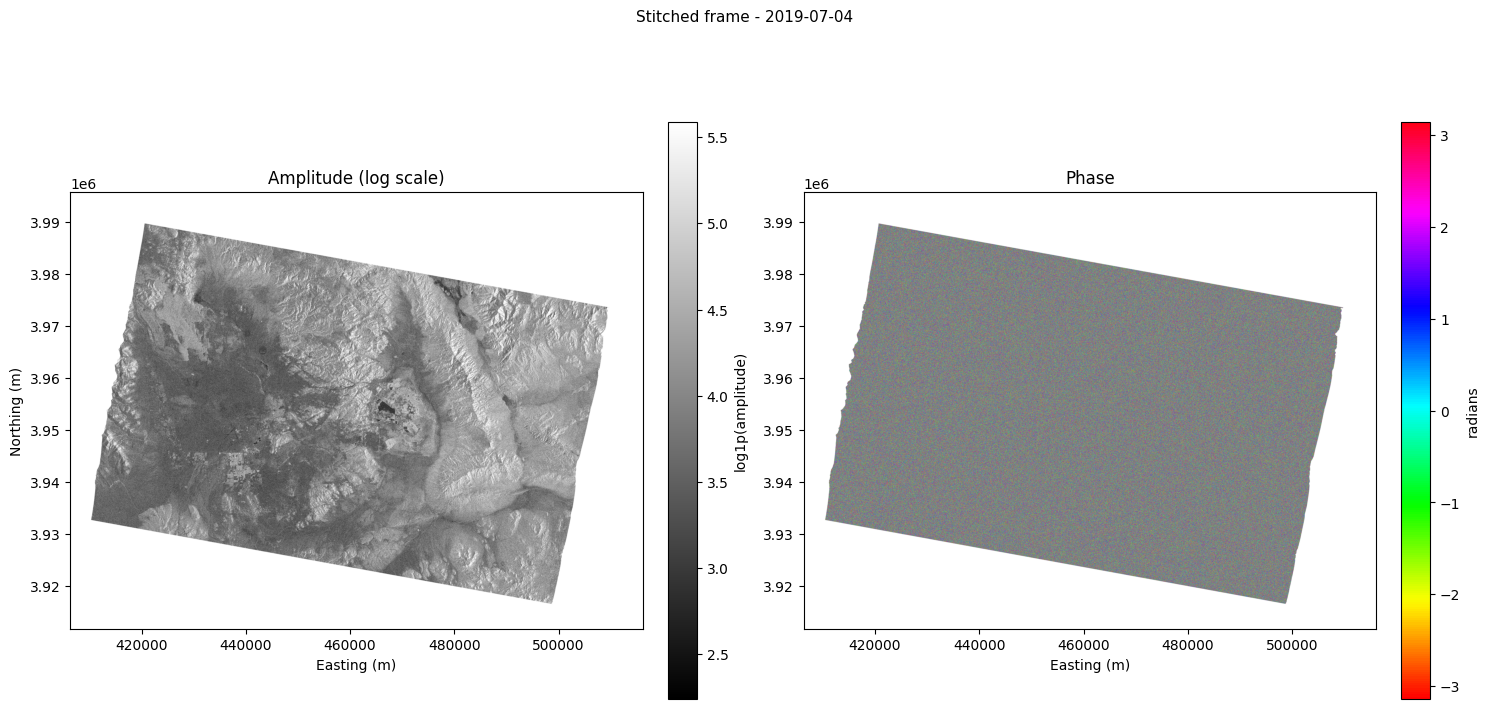

  saved ./Stitched_Frames/frame_20190704.png
  2019-07-16: native frame would be 8385 x 21978 (1.47 GB) - too big for a safe memory budget, downsampling by stride=3 -> 2795 x 7326 (0.16 GB), effective pixel spacing 15.0 x 30.0 m
    amplitude: min=0, max=5353, valid pixels=56.7%, log-stretch=[2.24, 5.59]


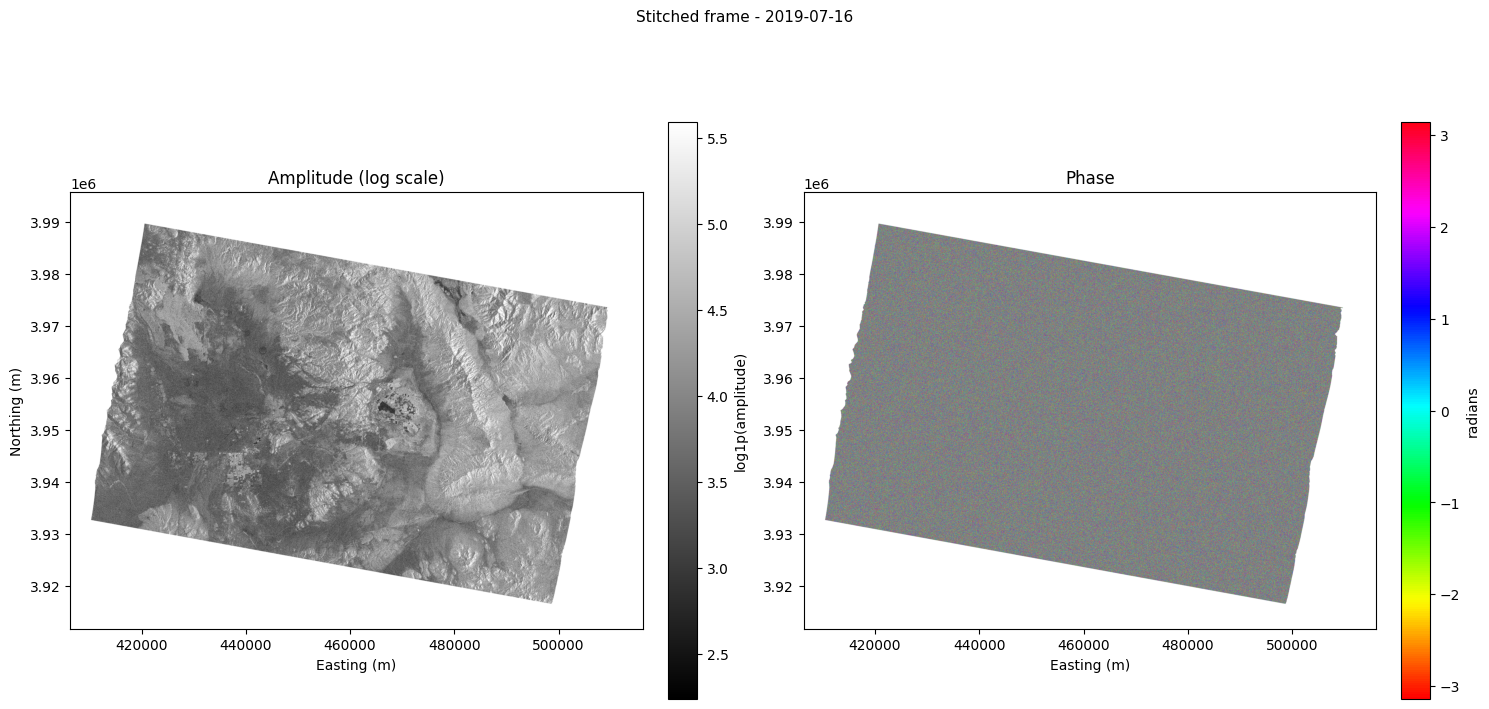

  saved ./Stitched_Frames/frame_20190716.png
Done - stitched frame PNGs saved to ./Stitched_Frames/


In [4]:
directory = "./Raw_data/"
files = sorted(glob.glob(os.path.join(directory, "*.h5")))
num_files = len(files)
print(f"Found {num_files} .h5 files in {directory}")

# --- Pass 1: cheap metadata only - no VV array loaded yet - so we can group bursts by
# acquisition date and work out each frame's mosaic geometry before touching any big arrays.
burstid = [None] * num_files
datestring = [None] * num_files
epsg = [None] * num_files
extent = [None] * num_files   # (x_min, x_max, y_min, y_max) per burst
xcoord = [None] * num_files
ycoord = [None] * num_files

for k, filepath in enumerate(files):
    with h5py.File(filepath, "r") as f:
        epsg[k] = int(f["/data/projection"][()])
        xcoord[k] = f["/data/x_coordinates"][()]
        ycoord[k] = f["/data/y_coordinates"][()]
        bid = f["/identification/burst_id"][()]
        burstid[k] = bid.decode() if isinstance(bid, bytes) else bid
        ds = f["/metadata/calibration_information/azimuth_time"][()]
        ds = ds.decode() if isinstance(ds, bytes) else ds
        datestring[k] = ds[:10]
    extent[k] = (float(xcoord[k].min()), float(xcoord[k].max()), float(ycoord[k].min()), float(ycoord[k].max()))

dates = sorted(set(datestring))
print(f"{num_files} bursts across {len(dates)} acquisition date(s): {dates}")

output_dir_png = "./Stitched_Frames/"
os.makedirs(output_dir_png, exist_ok=True)

A_frame = {}       # one amplitude array per DATE (only len(dates) of these, not len(files))
PHS_frame = {}     # one phase array per date
frame_extent = {}
frame_epsg = {}

# Conservative cap on the mosaic's own size. Plotting it needs several extra temporary
# copies on top (amplitude, phase, masked/log-stretched versions - see plot_amp_phase),
# so real peak memory during plotting is roughly 4-5x the mosaic's own size - this cap is
# kept small on purpose to leave a big safety margin, not just enough for the mosaic alone.
# If the native (full) resolution mosaic would be bigger than this, we downsample by an
# integer stride instead of crashing - applied at the HDF5 read itself (see below), so it
# shrinks each burst's own array too, not just the mosaic.
MAX_MOSAIC_GB = 0.2

for date in dates:
    idx_for_date = [k for k in range(num_files) if datestring[k] == date]

    # mosaic geometry: union bounding box of this date's bursts, pixel spacing taken from
    # the first burst (all bursts in a track/subswath share the same output resolution)
    x_min = min(extent[k][0] for k in idx_for_date)
    x_max = max(extent[k][1] for k in idx_for_date)
    y_min = min(extent[k][2] for k in idx_for_date)
    y_max = max(extent[k][3] for k in idx_for_date)
    dx = abs(xcoord[idx_for_date[0]][1] - xcoord[idx_for_date[0]][0])
    dy = abs(ycoord[idx_for_date[0]][1] - ycoord[idx_for_date[0]][0])
    n_cols_native = int(round((x_max - x_min) / dx)) + 1
    n_rows_native = int(round((y_max - y_min) / dy)) + 1
    native_gb = n_rows_native * n_cols_native * 8 / 1e9  # complex64 = 8 bytes/pixel

    stride = 1
    while (n_rows_native // stride) * (n_cols_native // stride) * 8 / 1e9 > MAX_MOSAIC_GB:
        stride += 1
    n_rows = n_rows_native // stride
    n_cols = n_cols_native // stride

    if stride > 1:
        print(f"  {date}: native frame would be {n_rows_native} x {n_cols_native} "
              f"({native_gb:.2f} GB) - too big for a safe memory budget, downsampling by "
              f"stride={stride} -> {n_rows} x {n_cols} ({n_rows * n_cols * 8 / 1e9:.2f} GB), "
              f"effective pixel spacing {dx * stride:.1f} x {dy * stride:.1f} m")
    else:
        print(f"  {date}: stitching {len(idx_for_date)} burst(s) into a {n_rows} x {n_cols} frame "
              f"({native_gb:.2f} GB)")

    mosaic = np.zeros((n_rows, n_cols), dtype=np.complex64)

    for k in idx_for_date:
        # stride applied at the HDF5 read itself (not after loading) - genuinely avoids
        # materialising the full-resolution burst array when stride > 1
        with h5py.File(files[k], "r") as f:
            vv = f["/data/VV"][::stride, ::stride]
        burst_data = vv if np.iscomplexobj(vv) else vv["r"] + 1j * vv["i"]

        col0 = int(round((xcoord[k][0] - x_min) / dx / stride))
        row0 = int(round((y_max - ycoord[k][0]) / dy / stride))
        rows = min(burst_data.shape[0], n_rows - row0)
        cols = min(burst_data.shape[1], n_cols - col0)
        burst_data = burst_data[:rows, :cols]
        region = mosaic[row0:row0 + rows, col0:col0 + cols]

        valid_burst = np.isfinite(burst_data) & (np.abs(burst_data) > 0)
        region[valid_burst] = burst_data[valid_burst]

        # this burst's own array is only needed to copy it into the mosaic - free it
        # straight away so we never hold more than one burst + the mosaic at once
        del vv, burst_data, valid_burst, region
        gc.collect()

    frame_extent[date] = (x_min, x_max, y_min, y_max)
    frame_epsg[date] = epsg[idx_for_date[0]]
    png_path = os.path.join(output_dir_png, f"frame_{date.replace('-', '')}.png")
    A_frame[date], PHS_frame[date] = plot_amp_phase(mosaic, frame_extent[date], f"Stitched frame - {date}", png_path)
    print(f"  saved {png_path}")

    del mosaic
    gc.collect()

print(f"Done - stitched frame PNGs saved to {output_dir_png}")

## 4. Explore the data (informational)

How many unique track-subswaths and unique bursts are there? How many
scenes per unique burst?

In [5]:
# How many unique track-subswaths, and how many unique bursts per track?
# how many scenes per unique burst?
burstid_unq = sorted(set(burstid))
print(f"{len(burstid_unq)} unique burst IDs out of {num_files} files:")
for b in burstid_unq:
    n_scenes = sum(1 for bid in burstid if bid == b)
    print(f"  {b}: {n_scenes} scene(s)")

3 unique burst IDs out of 6 files:
  t071_151217_iw2: 2 scene(s)
  t071_151218_iw2: 2 scene(s)
  t071_151219_iw2: 2 scene(s)


How many unique tracks (ignoring subswath)?

In [6]:
# How many unique tracks (ignoring subswath)?
tracku = sorted({b.split("_")[0] for b in burstid_unq})
print(f"{len(tracku)} unique track(s): {tracku}")

1 unique track(s): ['t071']


## 5. Download the stitched-frame PNGs

This zips up `./Stitched_Frames/` and downloads it to your computer, in
case you want copies outside of Colab. You've already seen every stitched
frame inline above in Section 3 - this step is optional.

In [7]:
import shutil
shutil.make_archive("Stitched_Frames", "zip", "Stitched_Frames")

from google.colab import files
files.download("Stitched_Frames.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>